# BTC/USDT Hybrid Trader Bot


In [2]:
import ccxt
import pandas as pd
import numpy as np
import time
import joblib
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('✅ Adım 1: Kütüphaneler Yüklendi')

✅ Adım 1: Kütüphaneler Yüklendi


In [3]:
# ─────────────────────────────────────────────
# ADIM 2: VERİ ÇEKİMİ - SABİT TARİH ARALIĞI
# ─────────────────────────────────────────────
exchange = ccxt.binance()

BASLANGIC_TARIHI = '2023-06-03T00:00:00Z'
BITIS_TARIHI     = '2026-06-02T23:00:00Z'

since = exchange.parse8601(BASLANGIC_TARIHI)
end_time = exchange.parse8601(BITIS_TARIHI)

all_bars = []

while since < end_time:
    try:
        bars = exchange.fetch_ohlcv(
            'BTC/USDT',
            '1h',
            since=since,
            limit=1000
        )

        if len(bars) == 0:
            break

        # Bitiş tarihinden sonraki mumları alma
        bars = [b for b in bars if b[0] <= end_time]

        all_bars.extend(bars)

        since = bars[-1][0] + (60 * 60 * 1000)

        time.sleep(0.1)

        if since > end_time:
            break

    except Exception as e:
        print('API Hatası:', e)
        break

df_raw = pd.DataFrame(
    all_bars,
    columns=['Tarih', 'Acilis', 'Yuksek', 'Dusuk', 'Kapanis', 'Hacim']
)

df_raw['Tarih'] = pd.to_datetime(df_raw['Tarih'], unit='ms')
df_raw.drop_duplicates(subset='Tarih', inplace=True)
df_raw.set_index('Tarih', inplace=True)
df_raw.sort_index(inplace=True)

print(f'✅ Sabit tarih aralığında ham veri çekildi!')
print(f'📅 Başlangıç: {df_raw.index.min()}')
print(f'📅 Bitiş    : {df_raw.index.max()}')
print(f'📊 Toplam Satır: {len(df_raw)}')

display(df_raw.head())
display(df_raw.tail())

✅ Sabit tarih aralığında ham veri çekildi!
📅 Başlangıç: 2023-06-03 00:00:00
📅 Bitiş    : 2026-06-02 23:00:00
📊 Toplam Satır: 26304


,Acilis,Yuksek,Dusuk,Kapanis,Hacim
Tarih,,,,,
2023-06-03 00:00:00,27242.59,27242.60,27152.20,27165.09,678.25975
2023-06-03 01:00:00,27165.08,27189.40,27092.00,27130.40,1101.74244
2023-06-03 02:00:00,27130.41,27169.26,27129.17,27153.26,612.83696
2023-06-03 03:00:00,27153.26,27171.47,27131.89,27143.20,323.04687
2023-06-03 04:00:00,27143.20,27163.77,27105.73,27160.24,420.01096


,Acilis,Yuksek,Dusuk,Kapanis,Hacim
Tarih,,,,,
2026-06-02 19:00:00,67341.99,67498.00,66432.00,67315.14,2333.17121
2026-06-02 20:00:00,67315.14,67689.65,66911.20,67587.77,1637.61606
2026-06-02 21:00:00,67587.78,67923.24,67412.00,67566.01,765.53933
2026-06-02 22:00:00,67566.01,67566.01,66244.02,66385.20,1856.41667
2026-06-02 23:00:00,66385.20,66868.62,66193.00,66760.83,1599.39304


In [4]:
# ─────────────────────────────────────────────
# ADIM 3: EDA
# ─────────────────────────────────────────────
print('--- DataFrame Bilgileri ---')
df_raw.info()
print('\n--- İstatistiksel Özet ---')
display(df_raw.describe().T)
print('\n--- Eksik Veri Kontrolü ---')
print(df_raw.isnull().sum())

--- DataFrame Bilgileri ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26304 entries, 2023-06-03 00:00:00 to 2026-06-02 23:00:00
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Acilis   26304 non-null  float64
 1   Yuksek   26304 non-null  float64
 2   Dusuk    26304 non-null  float64
 3   Kapanis  26304 non-null  float64
 4   Hacim    26304 non-null  float64
dtypes: float64(5)
memory usage: 1.2 MB

--- İstatistiksel Özet ---


,count,mean,std,min,25%,50%,75%,max
Acilis,26304.0,72603.289822,27520.103572,24923.51000,55358.27500,69984.175000,95594.985000,126011.18000
Yuksek,26304.0,72837.706428,27594.842759,24975.17000,55757.50000,70277.925000,95880.000000,126199.63000
Dusuk,26304.0,72359.950890,27441.908865,24800.00000,54962.71500,69677.880000,95286.835000,125252.74000
Kapanis,26304.0,72604.792481,27518.706884,24923.51000,55379.59250,69984.175000,95594.987500,126011.18000
Hacim,26304.0,1182.229054,1315.924282,46.43346,469.21449,790.885205,1396.857428,27563.36388



--- Eksik Veri Kontrolü ---
Acilis     0
Yuksek     0
Dusuk      0
Kapanis    0
Hacim      0
dtype: int64


In [5]:
# ─────────────────────────────────────────────
# ADIM 4: SPLIT → SONRA İNDİKATÖR 
# ─────────────────────────────────────────────
split_idx    = int(len(df_raw) * 0.80)
df_train_raw = df_raw.iloc[:split_idx].copy()
df_test_raw  = df_raw.iloc[split_idx:].copy()

print(f'Train: {len(df_train_raw)} satır  |  Test: {len(df_test_raw)} satır')


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()

    # Trend
    d['SMA_20']  = d['Kapanis'].rolling(20).mean()
    d['SMA_50']  = d['Kapanis'].rolling(50).mean()
    d['EMA_12']  = d['Kapanis'].ewm(span=12, adjust=False).mean()
    d['EMA_26']  = d['Kapanis'].ewm(span=26, adjust=False).mean()

    # Momentum
    delta = d['Kapanis'].diff()
    gain  = delta.where(delta > 0, 0).rolling(14).mean()
    loss  = (-delta.where(delta < 0, 0)).rolling(14).mean()
    d['RSI']         = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))
    d['MACD']        = d['EMA_12'] - d['EMA_26']
    d['MACD_Signal'] = d['MACD'].ewm(span=9, adjust=False).mean()
    d['MACD_Hist']   = d['MACD'] - d['MACD_Signal']

    # Bollinger Bands
    bb_mid           = d['Kapanis'].rolling(20).mean()
    bb_std           = d['Kapanis'].rolling(20).std()
    d['BB_Upper']    = bb_mid + 2 * bb_std
    d['BB_Lower']    = bb_mid - 2 * bb_std
    d['BB_Width']    = (d['BB_Upper'] - d['BB_Lower']) / bb_mid
    d['BB_Pos']      = (d['Kapanis'] - d['BB_Lower']) / (d['BB_Upper'] - d['BB_Lower'] + 1e-9)

    # ATR
    tr = pd.concat([
        d['Yuksek'] - d['Dusuk'],
        (d['Yuksek'] - d['Kapanis'].shift()).abs(),
        (d['Dusuk']  - d['Kapanis'].shift()).abs()
    ], axis=1).max(axis=1)
    d['ATR_14'] = tr.rolling(14).mean()

    # Stochastic %K
    low_14 = d['Dusuk'].rolling(14).min()
    high_14 = d['Yuksek'].rolling(14).max()
    d['Stoch_K'] = 100 * (d['Kapanis'] - low_14) / (high_14 - low_14 + 1e-9)

    # Hacim
    d['Hacim_SMA_20'] = d['Hacim'].rolling(20).mean()
    d['Hacim_Ratio']  = d['Hacim'] / (d['Hacim_SMA_20'] + 1e-9)

    # Getiri
    d['Getiri_%']  = d['Kapanis'].pct_change() * 100
    d['Getiri_3h'] = d['Kapanis'].pct_change(3) * 100

    # Hedef
    d['Hedef'] = (d['Kapanis'].shift(-1) > d['Kapanis']).astype(int)

    return d


df_train = add_features(df_train_raw).dropna().iloc[:-1]
df_test  = add_features(df_test_raw).dropna().iloc[:-1]

print(f'Train (temiz): {len(df_train)} satır')
print(f'Test  (temiz): {len(df_test)}  satır')

Train: 21043 satır  |  Test: 5261 satır
Train (temiz): 20992 satır
Test  (temiz): 5211  satır


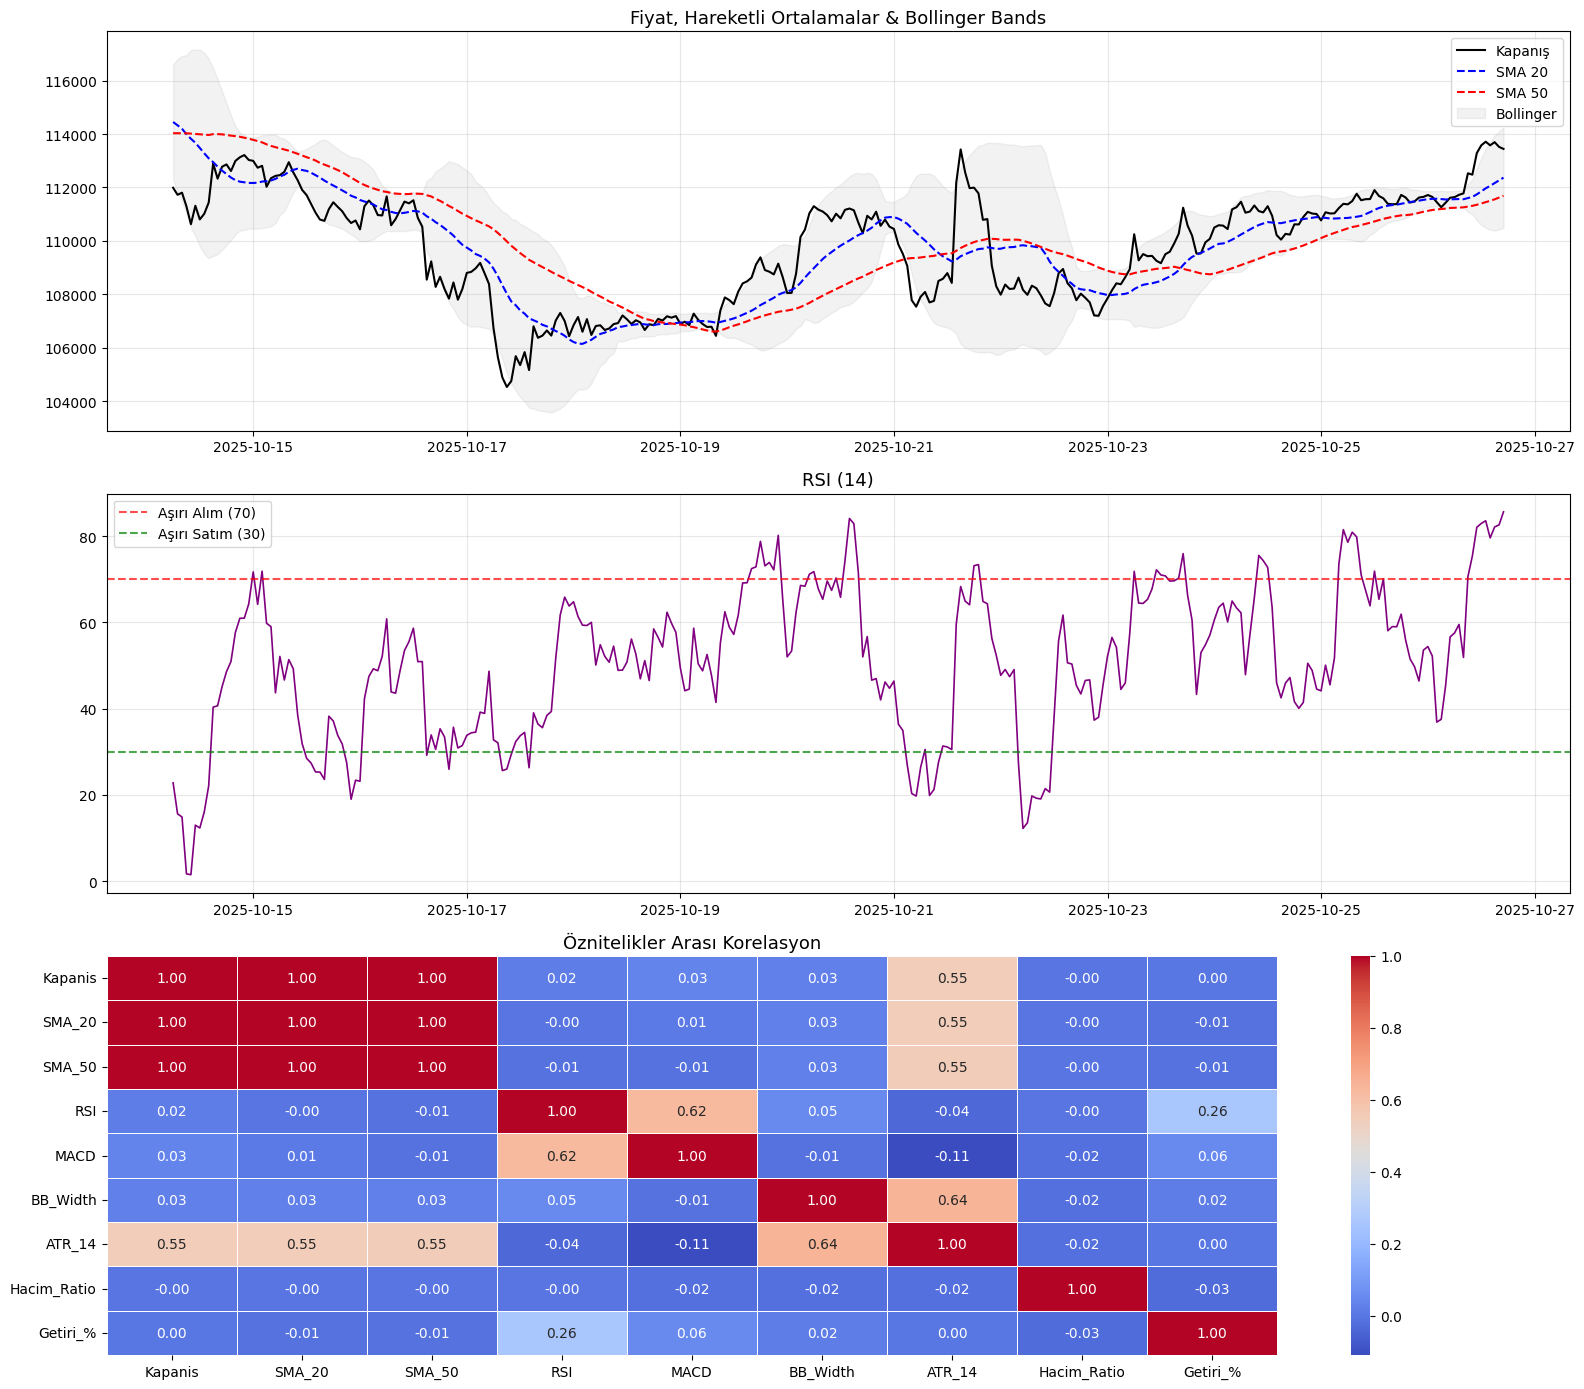

In [6]:
# ─────────────────────────────────────────────
# ADIM 5: GÖRSELLEŞTİRME
# ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

last = df_train.iloc[-300:]

ax = axes[0]
ax.plot(last.index, last['Kapanis'],   label='Kapanış',   color='black', lw=1.5)
ax.plot(last.index, last['SMA_20'],    label='SMA 20',    color='blue',  ls='--')
ax.plot(last.index, last['SMA_50'],    label='SMA 50',    color='red',   ls='--')
ax.fill_between(last.index, last['BB_Upper'], last['BB_Lower'], alpha=0.1, color='gray', label='Bollinger')
ax.set_title('Fiyat, Hareketli Ortalamalar & Bollinger Bands', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(last.index, last['RSI'], color='purple', lw=1.2)
ax2.axhline(70, color='red',   ls='--', alpha=0.7, label='Aşırı Alım (70)')
ax2.axhline(30, color='green', ls='--', alpha=0.7, label='Aşırı Satım (30)')
ax2.set_title('RSI (14)', fontsize=13)
ax2.legend(); ax2.grid(True, alpha=0.3)

kolon = ['Kapanis','SMA_20','SMA_50','RSI','MACD','BB_Width','ATR_14','Hacim_Ratio','Getiri_%']
sns.heatmap(df_train[kolon].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=axes[2])
axes[2].set_title('Öznitelikler Arası Korelasyon', fontsize=13)

plt.tight_layout()
plt.show()

In [7]:
# ─────────────────────────────────────────────
# ADIM 6: MODEL EĞİTİMİ
# ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

FEATURES = [
    'SMA_20', 'SMA_50', 'RSI', 'MACD', 'MACD_Hist',
    'BB_Width', 'BB_Pos', 'ATR_14',
    'Hacim_Ratio', 'Getiri_%', 'Getiri_3h'
]

X_train = df_train[FEATURES]
y_train = df_train['Hedef']
X_test  = df_test[FEATURES]
y_test  = df_test['Hedef']

oran = len(y_train[y_train == 0]) / max(1, len(y_train[y_train == 1]))
print(f'Sınıf oranı (0/1): {oran:.2f}')

rf_model   = RandomForestClassifier(
    n_estimators=200, max_depth=4, min_samples_split=40,
    class_weight='balanced', random_state=42, n_jobs=-1)

xgb_model  = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.01,
    reg_alpha=1.0, reg_lambda=2.0, scale_pos_weight=oran,
    random_state=42, n_jobs=-1, verbosity=0)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=200, max_depth=4, num_leaves=15, learning_rate=0.02,
    reg_alpha=1.5, reg_lambda=3.0, class_weight='balanced',
    random_state=42, n_jobs=-1, verbose=-1)

hybrid_model = VotingClassifier(
    estimators=[('RF', rf_model), ('XGB', xgb_model), ('LGBM', lgbm_model)],
    voting='soft', n_jobs=-1
)

hybrid_model.fit(X_train, y_train)
print('✅ Model eğitimi tamamlandı.')

Sınıf oranı (0/1): 0.96
✅ Model eğitimi tamamlandı.


🏆 NİHAİ MODEL METRİKLERİ
Eğitim Doğruluğu : %56.28
Test Doğruluğu   : %52.91
------------------------------------------------------------
                 precision    recall  f1-score   support

Düşüş/Yatay (0)       0.53      0.50      0.51      2614
   Yükseliş (1)       0.53      0.56      0.54      2597

       accuracy                           0.53      5211
      macro avg       0.53      0.53      0.53      5211
   weighted avg       0.53      0.53      0.53      5211

--- Karmaşıklık Matrisi ---
Gerçek Düşüş/Yatay - Tahmin Düşüş/Yatay : 1297
Gerçek Düşüş/Yatay - Tahmin Yükseliş    : 1317
Gerçek Yükseliş - Tahmin Düşüş/Yatay    : 1137
Gerçek Yükseliş - Tahmin Yükseliş       : 1460


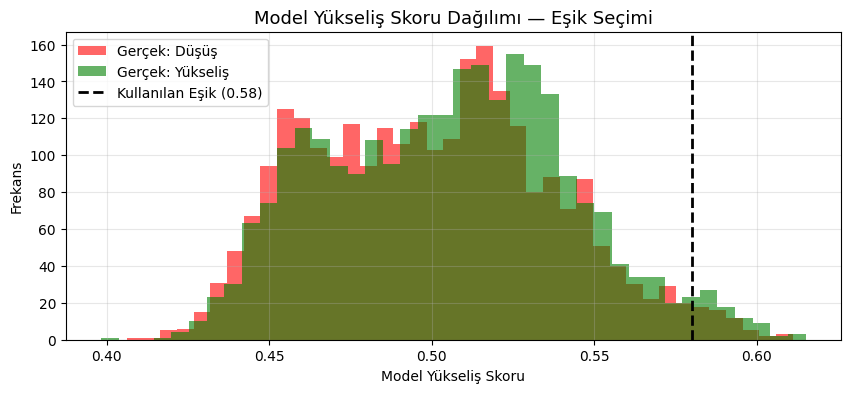


💾 Model kaydedildi → c:\Users\murat\OneDrive\Masaüstü\trader2\btc_hybrid_model.pkl
📊 Eğitim Doğruluğu : %56.28
📊 Test Doğruluğu   : %52.91
✅ Model doğruluğu dosyanın içine eklendi.


In [8]:
# ─────────────────────────────────────────────
# ADIM 7: MODEL METRİKLERİ
# ─────────────────────────────────────────────
train_pred = hybrid_model.predict(X_train)
y_pred     = hybrid_model.predict(X_test)
y_prob     = hybrid_model.predict_proba(X_test)[:, 1]

print('=' * 60)
print('🏆 NİHAİ MODEL METRİKLERİ')
print(f"Eğitim Doğruluğu : %{accuracy_score(y_train, train_pred)*100:.2f}")
print(f"Test Doğruluğu   : %{accuracy_score(y_test,  y_pred)*100:.2f}")
print('-' * 60)
print(classification_report(y_test, y_pred,
      target_names=['Düşüş/Yatay (0)', 'Yükseliş (1)']))

cm = confusion_matrix(y_test, y_pred)
print('--- Karmaşıklık Matrisi ---')
print(f'Gerçek Düşüş/Yatay - Tahmin Düşüş/Yatay : {cm[0][0]}')
print(f'Gerçek Düşüş/Yatay - Tahmin Yükseliş    : {cm[0][1]}')
print(f'Gerçek Yükseliş - Tahmin Düşüş/Yatay    : {cm[1][0]}')
print(f'Gerçek Yükseliş - Tahmin Yükseliş       : {cm[1][1]}')
print('=' * 60)

# Güven dağılımını gör — eşik seçmeye yardımcı olur
plt.figure(figsize=(10, 4))
plt.hist(y_prob[y_test == 0], bins=40, alpha=0.6, color='red',   label='Gerçek: Düşüş')
plt.hist(y_prob[y_test == 1], bins=40, alpha=0.6, color='green', label='Gerçek: Yükseliş')
plt.axvline(0.58, color='black', ls='--', lw=2, label='Kullanılan Eşik (0.58)')
plt.title('Model Yükseliş Skoru Dağılımı — Eşik Seçimi', fontsize=13)
plt.xlabel('Model Yükseliş Skoru'); plt.ylabel('Frekans')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# Model dosyasını app1.py'nin doğrudan okuyabileceği şekilde kaydet
# Doğruluk değeri app içinde yeniden hesaplanmaz; model dosyasından okunur.
from datetime import datetime
from pathlib import Path

train_accuracy_pct = round(accuracy_score(y_train, train_pred) * 100, 2)
test_accuracy_pct  = round(accuracy_score(y_test, y_pred) * 100, 2)

hybrid_model.train_accuracy_pct = train_accuracy_pct
hybrid_model.test_accuracy_pct  = test_accuracy_pct
hybrid_model.features           = FEATURES
hybrid_model.created_at         = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
hybrid_model.source             = 'Jupyter Notebook'
hybrid_model.confusion_matrix_  = cm.tolist()
hybrid_model.classification_report_ = classification_report(
    y_test,
    y_pred,
    target_names=['Düşüş/Yatay (0)', 'Yükseliş (1)'],
    output_dict=True
)

MODEL_PATH = Path.cwd() / 'btc_hybrid_model.pkl'
joblib.dump(hybrid_model, MODEL_PATH)

print(f'\n💾 Model kaydedildi → {MODEL_PATH}')
print(f'📊 Eğitim Doğruluğu : %{train_accuracy_pct:.2f}')
print(f'📊 Test Doğruluğu   : %{test_accuracy_pct:.2f}')
print('✅ Model doğruluğu dosyanın içine eklendi.')

In [9]:
# ─────────────────────────────────────────────
# 8.ADIM:BACKTEST PARAMETRE OPTİMİZASYONU
# ─────────────────────────────────────────────

def backtest_parametre(confidence, stop_loss, take_profit, min_bekle, pozisyon_oran, strong_confidence=0.70):
    KOMISYON  = 0.0001
    BASLANGIC = 10_000

    bakiye = BASLANGIC
    pozisyon = 0.0
    alis_fiyat = 0.0
    son_islem_idx = -min_bekle
    toplam_komisyon = 0.0
    kayitlar = []

    temp_df = df_test.copy()
    temp_df['Prob'] = y_prob
    temp_df['Sinyal'] = (temp_df['Prob'] >= confidence).astype(int)

    for i in range(len(temp_df) - 1):
        row = temp_df.iloc[i]
        fiyat = row['Kapanis']

        # Stop-Loss / Take-Profit
        if pozisyon > 0:
            degisim = (fiyat - alis_fiyat) / alis_fiyat

            if degisim <= -stop_loss or degisim >= take_profit:
                komisyon = pozisyon * fiyat * KOMISYON
                gelir = pozisyon * fiyat - komisyon
                net_pnl_usd = gelir - (alis_fiyat * pozisyon)

                bakiye += gelir
                toplam_komisyon += komisyon

                tip = 'SAT-SL' if degisim <= -stop_loss else 'SAT-TP'

                kayitlar.append({
                    'Tip': tip,
                    'Fiyat': fiyat,
                    'Bakiye': bakiye,
                    'Net_PnL_USD': net_pnl_usd
                })

                pozisyon = 0.0
                son_islem_idx = i
                continue

        # AL — normal sinyal veya güçlü sinyal
        normal_al = row['Prob'] >= confidence and (i - son_islem_idx) >= min_bekle
        guclu_al  = row['Prob'] >= strong_confidence

        if pozisyon == 0 and (normal_al or guclu_al):
            harcama = bakiye * pozisyon_oran
            komisyon = harcama * KOMISYON

            pozisyon = (harcama - komisyon) / fiyat
            bakiye -= harcama
            toplam_komisyon += komisyon
            alis_fiyat = fiyat
            son_islem_idx = i

            kayitlar.append({
                'Tip': 'AL',
                'Fiyat': fiyat,
                'Bakiye': bakiye,
                'Net_PnL_USD': 0
            })

        # SAT
        elif row['Sinyal'] == 0 and pozisyon > 0 and (i - son_islem_idx) >= min_bekle:
            komisyon = pozisyon * fiyat * KOMISYON
            gelir = pozisyon * fiyat - komisyon
            net_pnl_usd = gelir - (alis_fiyat * pozisyon)

            bakiye += gelir
            toplam_komisyon += komisyon

            kayitlar.append({
                'Tip': 'SAT',
                'Fiyat': fiyat,
                'Bakiye': bakiye,
                'Net_PnL_USD': net_pnl_usd
            })

            pozisyon = 0.0
            son_islem_idx = i

    # Açık pozisyonu finalde kapat
    if pozisyon > 0:
        son_fiyat = temp_df['Kapanis'].iloc[-1]
        komisyon = pozisyon * son_fiyat * KOMISYON
        gelir = pozisyon * son_fiyat - komisyon
        net_pnl_usd = gelir - (alis_fiyat * pozisyon)

        bakiye += gelir
        toplam_komisyon += komisyon

        kayitlar.append({
            'Tip': 'SAT-FINAL',
            'Fiyat': son_fiyat,
            'Bakiye': bakiye,
            'Net_PnL_USD': net_pnl_usd
        })

    islem_df_temp = pd.DataFrame(kayitlar)

    kar = bakiye - BASLANGIC
    getiri = kar / BASLANGIC * 100

    if len(islem_df_temp) > 0:
        sat_df_temp = islem_df_temp[islem_df_temp['Tip'].isin(['SAT', 'SAT-SL', 'SAT-TP', 'SAT-FINAL'])]
        kazanan = (sat_df_temp['Net_PnL_USD'] > 0).sum()
        kaybeden = (sat_df_temp['Net_PnL_USD'] <= 0).sum()
        win_rate = kazanan / max(1, len(sat_df_temp)) * 100
        toplam_sat = len(sat_df_temp)
    else:
        kazanan = 0
        kaybeden = 0
        win_rate = 0
        toplam_sat = 0

    return {
        'CONFIDENCE': confidence,
        'STRONG_CONFIDENCE': strong_confidence,
        'STOP_LOSS': stop_loss,
        'TAKE_PROFIT': take_profit,
        'MIN_BEKLE': min_bekle,
        'POZISYON_ORAN': pozisyon_oran,
        'Bitiş Bakiye': bakiye,
        'Net Kar/Zarar': kar,
        'Net Getiri %': getiri,
        'Toplam İşlem': len(islem_df_temp),
        'Kapatılan İşlem': toplam_sat,
        'Win Rate %': win_rate,
        'Kazanan': kazanan,
        'Kaybeden': kaybeden,
        'Toplam Komisyon': toplam_komisyon
    }


sonuclar = []

for conf in [0.55, 0.58, 0.60, 0.62, 0.64, 0.66]:
    for sl in [0.015, 0.020, 0.025, 0.030]:
        for tp in [0.030, 0.040, 0.050, 0.070]:
            for bekle in [6, 12, 18, 24]:
                for oran in [0.50, 0.60, 0.70, 0.80]:
                    sonuc = backtest_parametre(conf, sl, tp, bekle, oran)
                    sonuclar.append(sonuc)

opt_df = pd.DataFrame(sonuclar)
opt_df = opt_df.sort_values(by='Net Getiri %', ascending=False)

print("✅ En iyi 20 parametre kombinasyonu:")
display(opt_df.head(20))

print("🟢 Pozitif getiri veren kombinasyonlar:")
display(opt_df[opt_df['Net Getiri %'] > 0].head(20))

✅ En iyi 20 parametre kombinasyonu:


,CONFIDENCE,STRONG_CONFIDENCE,STOP_LOSS,TAKE_PROFIT,MIN_BEKLE,POZISYON_ORAN,Bitiş Bakiye,Net Kar/Zarar,Net Getiri %,Toplam İşlem,Kapatılan İşlem,Win Rate %,Kazanan,Kaybeden,Toplam Komisyon
259,0.58,0.7,0.015,0.03,6,0.8,12662.185406,2662.185406,26.621854,174,87,59.770115,52,35,157.668392
323,0.58,0.7,0.020,0.03,6,0.8,12576.628376,2576.628376,25.766284,172,86,59.302326,51,35,155.615111
291,0.58,0.7,0.015,0.05,6,0.8,12537.444886,2537.444886,25.374449,174,87,59.770115,52,35,156.347821
307,0.58,0.7,0.015,0.07,6,0.8,12520.848401,2520.848401,25.208484,174,87,59.770115,52,35,156.251055
387,0.58,0.7,0.025,0.03,6,0.8,12503.324483,2503.324483,25.033245,172,86,59.302326,51,35,154.714545
355,0.58,0.7,0.020,0.05,6,0.8,12452.730715,2452.730715,24.527307,172,86,59.302326,51,35,154.299313
371,0.58,0.7,0.020,0.07,6,0.8,12436.246371,2436.246371,24.362464,172,86,59.302326,51,35,154.203069
275,0.58,0.7,0.015,0.04,6,0.8,12421.957658,2421.957658,24.219577,174,87,59.770115,52,35,155.762576
419,0.58,0.7,0.025,0.05,6,0.8,12380.148969,2380.148969,23.801490,172,86,59.302326,51,35,153.408182
435,0.58,0.7,0.025,0.07,6,0.8,12363.760705,2363.760705,23.637607,172,86,59.302326,51,35,153.312546


🟢 Pozitif getiri veren kombinasyonlar:


,CONFIDENCE,STRONG_CONFIDENCE,STOP_LOSS,TAKE_PROFIT,MIN_BEKLE,POZISYON_ORAN,Bitiş Bakiye,Net Kar/Zarar,Net Getiri %,Toplam İşlem,Kapatılan İşlem,Win Rate %,Kazanan,Kaybeden,Toplam Komisyon
259,0.58,0.7,0.015,0.03,6,0.8,12662.185406,2662.185406,26.621854,174,87,59.770115,52,35,157.668392
323,0.58,0.7,0.020,0.03,6,0.8,12576.628376,2576.628376,25.766284,172,86,59.302326,51,35,155.615111
291,0.58,0.7,0.015,0.05,6,0.8,12537.444886,2537.444886,25.374449,174,87,59.770115,52,35,156.347821
307,0.58,0.7,0.015,0.07,6,0.8,12520.848401,2520.848401,25.208484,174,87,59.770115,52,35,156.251055
387,0.58,0.7,0.025,0.03,6,0.8,12503.324483,2503.324483,25.033245,172,86,59.302326,51,35,154.714545
355,0.58,0.7,0.020,0.05,6,0.8,12452.730715,2452.730715,24.527307,172,86,59.302326,51,35,154.299313
371,0.58,0.7,0.020,0.07,6,0.8,12436.246371,2436.246371,24.362464,172,86,59.302326,51,35,154.203069
275,0.58,0.7,0.015,0.04,6,0.8,12421.957658,2421.957658,24.219577,174,87,59.770115,52,35,155.762576
419,0.58,0.7,0.025,0.05,6,0.8,12380.148969,2380.148969,23.801490,172,86,59.302326,51,35,153.408182
435,0.58,0.7,0.025,0.07,6,0.8,12363.760705,2363.760705,23.637607,172,86,59.302326,51,35,153.312546


In [10]:
# ─────────────────────────────────────────────
# ADIM 8.1: BACKTEST 
# ─────────────────────────────────────────────

KOMISYON      = 0.0001
BASLANGIC     = 10_000
POZISYON_ORAN = 0.80
CONFIDENCE    = 0.58
STRONG_CONFIDENCE = 0.70
STOP_LOSS     = 0.015
TAKE_PROFIT   = 0.030
MIN_BEKLE     = 6

bakiye          = BASLANGIC
pozisyon        = 0.0
alis_fiyat      = 0.0
son_islem_idx   = -MIN_BEKLE
toplam_komisyon = 0.0

kayitlar = []

test_df = df_test.copy()
test_df['Prob'] = y_prob
test_df['Sinyal'] = (test_df['Prob'] >= CONFIDENCE).astype(int)

for i in range(len(test_df) - 1):
    row = test_df.iloc[i]
    fiyat = row['Kapanis']

    # ─────────────────────────────────────────
    # 1) Açık pozisyon varsa önce SL / TP kontrolü
    # ─────────────────────────────────────────
    if pozisyon > 0:
        degisim = (fiyat - alis_fiyat) / alis_fiyat

        if degisim <= -STOP_LOSS or degisim >= TAKE_PROFIT:
            komisyon = pozisyon * fiyat * KOMISYON
            gelir = pozisyon * fiyat - komisyon

            net_pnl_usd = gelir - (alis_fiyat * pozisyon)

            bakiye += gelir
            toplam_komisyon += komisyon

            tip = 'SAT-SL' if degisim <= -STOP_LOSS else 'SAT-TP'

            kayitlar.append({
                'Tarih': row.name,
                'Tip': tip,
                'Fiyat': fiyat,
                'Bakiye': bakiye,
                'Fiyat_Degisim_%': degisim * 100,
                'Net_PnL_USD': net_pnl_usd
            })

            pozisyon = 0.0
            son_islem_idx = i
            continue

    # ─────────────────────────────────────────
    # 2) AL — normal sinyal veya güçlü sinyal
    # ─────────────────────────────────────────
    normal_al = row['Prob'] >= CONFIDENCE and (i - son_islem_idx) >= MIN_BEKLE
    guclu_al  = row['Prob'] >= STRONG_CONFIDENCE

    if pozisyon == 0 and (normal_al or guclu_al):
        harcama = bakiye * POZISYON_ORAN
        komisyon = harcama * KOMISYON

        pozisyon = (harcama - komisyon) / fiyat
        bakiye -= harcama
        toplam_komisyon += komisyon
        alis_fiyat = fiyat

        # ÖNEMLİ DÜZELTME:
        # AL işleminden sonra da son işlem index'i güncellenmeli.
        son_islem_idx = i

        kayitlar.append({
            'Tarih': row.name,
            'Tip': 'AL',
            'Fiyat': fiyat,
            'Bakiye': bakiye,
            'Fiyat_Degisim_%': 0,
            'Net_PnL_USD': 0
        })

    # ─────────────────────────────────────────
    # 3) SAT — model sinyali düşerse satış
    # ─────────────────────────────────────────
    elif row['Sinyal'] == 0 and pozisyon > 0 and (i - son_islem_idx) >= MIN_BEKLE:
        degisim = (fiyat - alis_fiyat) / alis_fiyat

        komisyon = pozisyon * fiyat * KOMISYON
        gelir = pozisyon * fiyat - komisyon

        net_pnl_usd = gelir - (alis_fiyat * pozisyon)

        bakiye += gelir
        toplam_komisyon += komisyon

        kayitlar.append({
            'Tarih': row.name,
            'Tip': 'SAT',
            'Fiyat': fiyat,
            'Bakiye': bakiye,
            'Fiyat_Degisim_%': degisim * 100,
            'Net_PnL_USD': net_pnl_usd
        })

        pozisyon = 0.0
        son_islem_idx = i


# ─────────────────────────────────────────────
# 4) Backtest sonunda açık pozisyon varsa kapat
# ─────────────────────────────────────────────
if pozisyon > 0:
    son_fiyat = test_df['Kapanis'].iloc[-1]
    degisim = (son_fiyat - alis_fiyat) / alis_fiyat

    komisyon = pozisyon * son_fiyat * KOMISYON
    gelir = pozisyon * son_fiyat - komisyon

    net_pnl_usd = gelir - (alis_fiyat * pozisyon)

    bakiye += gelir
    toplam_komisyon += komisyon

    kayitlar.append({
        'Tarih': test_df.index[-1],
        'Tip': 'SAT-FINAL',
        'Fiyat': son_fiyat,
        'Bakiye': bakiye,
        'Fiyat_Degisim_%': degisim * 100,
        'Net_PnL_USD': net_pnl_usd
    })

    pozisyon = 0.0


# ─────────────────────────────────────────────
# 5) Sonuç hesaplama
# ─────────────────────────────────────────────
kar = bakiye - BASLANGIC
yuzde = (kar / BASLANGIC) * 100

islem_df = pd.DataFrame(kayitlar) if kayitlar else pd.DataFrame(
    columns=['Tarih', 'Tip', 'Fiyat', 'Bakiye', 'Fiyat_Degisim_%', 'Net_PnL_USD']
)

bah_getiri = ((test_df['Kapanis'].iloc[-1] - test_df['Kapanis'].iloc[0])
              / test_df['Kapanis'].iloc[0]) * 100


# ─────────────────────────────────────────────
# 6) Raporlama
# ─────────────────────────────────────────────
if len(islem_df) == 0:
    sinyal_sayisi = test_df['Sinyal'].sum()

    print('⚠️ UYARI: Hiç işlem oluşmadı!')
    print(f'CONFIDENCE = {CONFIDENCE}')
    print(f'Test setindeki ham AL sinyali sayısı: {sinyal_sayisi}')
    print(f'MIN_BEKLE = {MIN_BEKLE} saatlik mum')
    print('CONFIDENCE değerini 0.58 veya 0.55 olarak deneyebilirsin.')

else:
    sat_df = islem_df[islem_df['Tip'].isin(['SAT', 'SAT-SL', 'SAT-TP', 'SAT-FINAL'])]

    kazanan = (sat_df['Net_PnL_USD'] > 0).sum() if len(sat_df) > 0 else 0
    kaybeden = (sat_df['Net_PnL_USD'] <= 0).sum() if len(sat_df) > 0 else 0
    win_rate = kazanan / max(1, len(sat_df)) * 100

    toplam_al = (islem_df['Tip'] == 'AL').sum()
    toplam_sat = len(sat_df)

    print('=' * 62)
    print('📊 BACKTEST SONUÇLARI  (v4 - Düzeltilmiş)')
    print(f'Başlangıç Sermaye     : ${BASLANGIC:,.0f}')
    print(f'Bitiş Bakiye          : ${bakiye:,.2f}')
    print(f'Net Kâr/Zarar         : ${kar:+,.2f}  ({yuzde:+.2f}%)')
    print(f'Toplam İşlem Kaydı    : {len(islem_df)}')
    print(f'Toplam AL İşlemi      : {toplam_al}')
    print(f'Toplam SAT İşlemi     : {toplam_sat}')
    print(f'Toplam Komisyon       : ${toplam_komisyon:,.2f}')
    print(f'Win Rate              : %{win_rate:.1f}  ({kazanan}✅ / {kaybeden}❌)')
    print('-' * 62)
    print(f'📌 Buy & Hold Getiri   : %{bah_getiri:+.2f}')
    print(f'🤖 Bot Getiri          : %{yuzde:+.2f}')

    sonuc = '🟢 Bot daha iyi performans gösterdi!' if yuzde > bah_getiri else '🔴 Buy & Hold daha iyi performans gösterdi'
    print(f'Sonuç                 : {sonuc}')
    print('=' * 62)

display(islem_df.tail(10))

📊 BACKTEST SONUÇLARI  (v4 - Düzeltilmiş)
Başlangıç Sermaye     : $10,000
Bitiş Bakiye          : $12,662.19
Net Kâr/Zarar         : $+2,662.19  (+26.62%)
Toplam İşlem Kaydı    : 174
Toplam AL İşlemi      : 87
Toplam SAT İşlemi     : 87
Toplam Komisyon       : $157.67
Win Rate              : %59.8  (52✅ / 35❌)
--------------------------------------------------------------
📌 Buy & Hold Getiri   : %-41.15
🤖 Bot Getiri          : %+26.62
Sonuç                 : 🟢 Bot daha iyi performans gösterdi!


,Tarih,Tip,Fiyat,Bakiye,Fiyat_Degisim_%,Net_PnL_USD
164,2026-04-30 04:00:00,AL,75497.00,2548.785851,0.000000,0.000000
165,2026-04-30 10:00:00,SAT,76028.66,12813.671539,0.704213,70.761796
166,2026-05-01 20:00:00,AL,77880.18,2562.734308,0.000000,0.000000
167,2026-05-02 02:00:00,SAT,78353.93,12873.966074,0.608306,61.319630
168,2026-05-06 13:00:00,AL,81670.89,2574.793215,0.000000,0.000000
169,2026-05-06 19:00:00,SAT,81464.87,12845.931222,-0.252256,-27.004935
170,2026-05-27 21:00:00,AL,74473.01,2569.186244,0.000000,0.000000
171,2026-05-28 03:00:00,SAT-SL,73258.01,12676.248159,-1.631464,-168.655388
172,2026-06-01 21:00:00,AL,71038.01,2535.249632,0.000000,0.000000
173,2026-06-02 03:00:00,SAT,70953.69,12662.185406,-0.118697,-13.048654


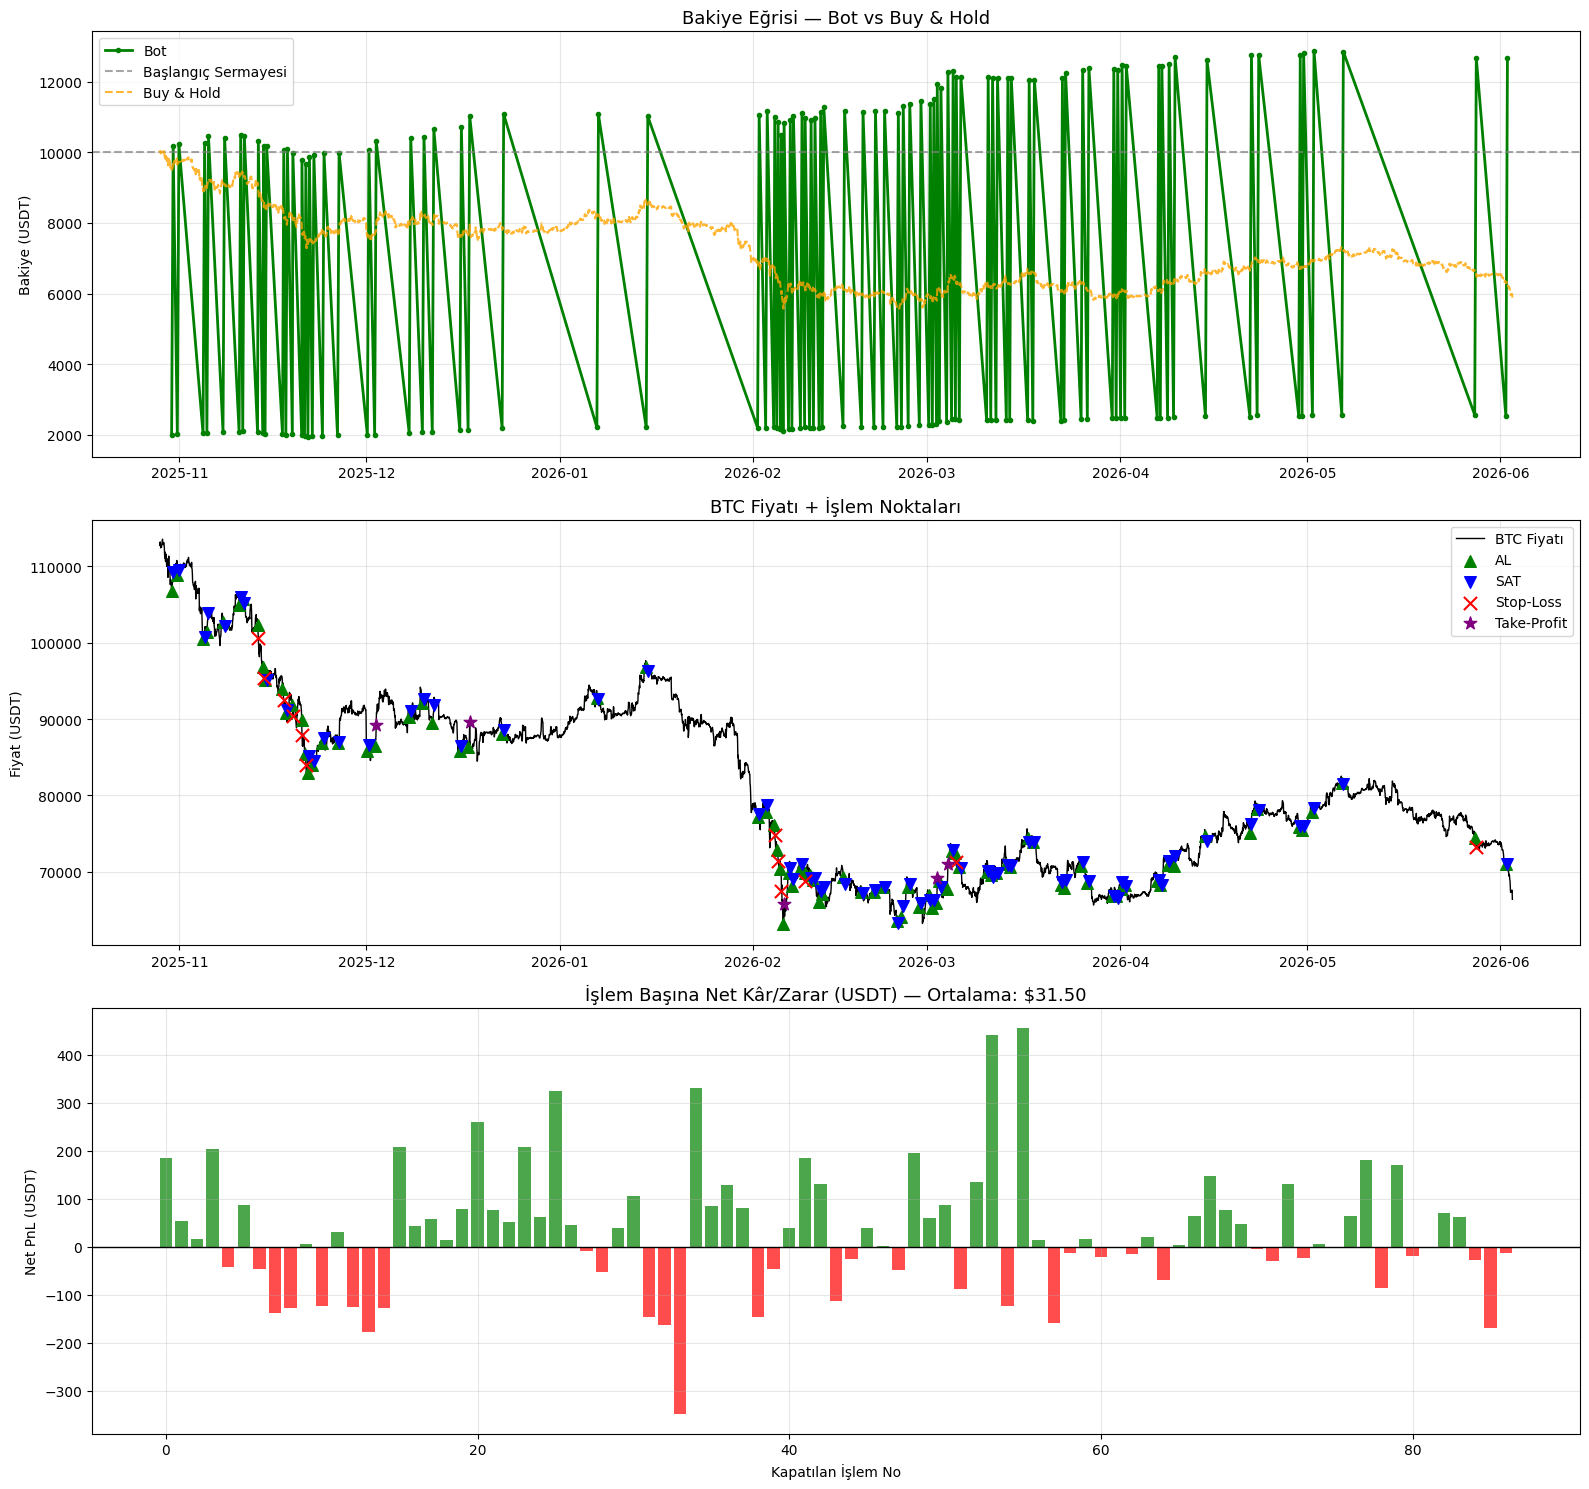


💸 Komisyon Analizi
   Toplam Komisyon  : $157.67
   Komisyon/Sermaye : %1.58
   İşlem kaydı başı : $0.91

📌 Kapatılan İşlem Özeti
   Kapatılan işlem sayısı : 87
   Ortalama Net PnL       : $31.50
   En iyi işlem           : $456.78
   En kötü işlem          : $-349.89


In [11]:
# ─────────────────────────────────────────────
# ADIM 9: BACKTEST GÖRSELLEŞTİRME - v4 UYUMLU
# ─────────────────────────────────────────────

if len(islem_df) == 0:
    print('⚠️ Hiç işlem oluşmadı — görselleştirme atlandı.')
    print('CONFIDENCE değerini 0.60, 0.58 veya 0.55 olarak deneyip Adım 8’i tekrar çalıştır.')
else:
    # SAT işlemleri yeniden hesaplanıyor
    sat_df = islem_df[islem_df['Tip'].isin(['SAT', 'SAT-SL', 'SAT-TP', 'SAT-FINAL'])]

    bah_getiri = (
        (test_df['Kapanis'].iloc[-1] - test_df['Kapanis'].iloc[0])
        / test_df['Kapanis'].iloc[0]
    ) * 100

    fig, axes = plt.subplots(3, 1, figsize=(16, 15))

    # ─────────────────────────────────────────
    # 1. Bakiye eğrisi vs Buy & Hold
    # ─────────────────────────────────────────
    ax0 = axes[0]

    ax0.plot(
        islem_df['Tarih'],
        islem_df['Bakiye'],
        color='green',
        lw=2,
        marker='o',
        ms=3,
        label='Bot'
    )

    ax0.axhline(
        BASLANGIC,
        color='gray',
        ls='--',
        alpha=0.7,
        label='Başlangıç Sermayesi'
    )

    bah_norm = test_df['Kapanis'] / test_df['Kapanis'].iloc[0] * BASLANGIC

    ax0.plot(
        test_df.index,
        bah_norm,
        color='orange',
        lw=1.5,
        ls='--',
        alpha=0.8,
        label='Buy & Hold'
    )

    ax0.set_title('Bakiye Eğrisi — Bot vs Buy & Hold', fontsize=13)
    ax0.set_ylabel('Bakiye (USDT)')
    ax0.legend()
    ax0.grid(True, alpha=0.3)

    # ─────────────────────────────────────────
    # 2. BTC fiyatı + işlem noktaları
    # ─────────────────────────────────────────
    ax1 = axes[1]

    ax1.plot(
        test_df.index,
        test_df['Kapanis'],
        color='black',
        lw=1,
        label='BTC Fiyatı'
    )

    al_df = islem_df[islem_df['Tip'] == 'AL']
    sat_df2 = islem_df[islem_df['Tip'] == 'SAT']
    sl_df = islem_df[islem_df['Tip'] == 'SAT-SL']
    tp_df = islem_df[islem_df['Tip'] == 'SAT-TP']
    final_df = islem_df[islem_df['Tip'] == 'SAT-FINAL']

    if len(al_df) > 0:
        ax1.scatter(
            al_df['Tarih'],
            al_df['Fiyat'],
            color='green',
            marker='^',
            s=70,
            zorder=5,
            label='AL'
        )

    if len(sat_df2) > 0:
        ax1.scatter(
            sat_df2['Tarih'],
            sat_df2['Fiyat'],
            color='blue',
            marker='v',
            s=70,
            zorder=5,
            label='SAT'
        )

    if len(sl_df) > 0:
        ax1.scatter(
            sl_df['Tarih'],
            sl_df['Fiyat'],
            color='red',
            marker='x',
            s=90,
            zorder=5,
            label='Stop-Loss'
        )

    if len(tp_df) > 0:
        ax1.scatter(
            tp_df['Tarih'],
            tp_df['Fiyat'],
            color='purple',
            marker='*',
            s=90,
            zorder=5,
            label='Take-Profit'
        )

    if len(final_df) > 0:
        ax1.scatter(
            final_df['Tarih'],
            final_df['Fiyat'],
            color='orange',
            marker='s',
            s=80,
            zorder=5,
            label='Final Satış'
        )

    ax1.set_title('BTC Fiyatı + İşlem Noktaları', fontsize=13)
    ax1.set_ylabel('Fiyat (USDT)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # ─────────────────────────────────────────
    # 3. İşlem başına net PnL dağılımı
    # ─────────────────────────────────────────
    ax2 = axes[2]

    if len(sat_df) > 0:
        renkler = ['green' if x > 0 else 'red' for x in sat_df['Net_PnL_USD']]

        ax2.bar(
            range(len(sat_df)),
            sat_df['Net_PnL_USD'].values,
            color=renkler,
            alpha=0.7
        )

        ax2.axhline(0, color='black', lw=1)

        ort_pnl = sat_df['Net_PnL_USD'].mean()

        ax2.set_title(
            f'İşlem Başına Net Kâr/Zarar (USDT) — Ortalama: ${ort_pnl:.2f}',
            fontsize=13
        )

        ax2.set_xlabel('Kapatılan İşlem No')
        ax2.set_ylabel('Net PnL (USDT)')
        ax2.grid(True, alpha=0.3)

    else:
        ax2.text(
            0.5,
            0.5,
            'Henüz kapatılan işlem yok',
            ha='center',
            va='center',
            transform=ax2.transAxes
        )

    plt.tight_layout()
    plt.show()

    # ─────────────────────────────────────────
    # Komisyon analizi
    # ─────────────────────────────────────────
    print('\n💸 Komisyon Analizi')
    print(f'   Toplam Komisyon  : ${toplam_komisyon:,.2f}')
    print(f'   Komisyon/Sermaye : %{toplam_komisyon / BASLANGIC * 100:.2f}')
    print(f'   İşlem kaydı başı : ${toplam_komisyon / max(1, len(islem_df)):.2f}')

    if len(sat_df) > 0:
        print('\n📌 Kapatılan İşlem Özeti')
        print(f'   Kapatılan işlem sayısı : {len(sat_df)}')
        print(f'   Ortalama Net PnL       : ${sat_df["Net_PnL_USD"].mean():.2f}')
        print(f'   En iyi işlem           : ${sat_df["Net_PnL_USD"].max():.2f}')
        print(f'   En kötü işlem          : ${sat_df["Net_PnL_USD"].min():.2f}')

In [12]:
# ─────────────────────────────────────────────
# 10: CANLI SİNYAL  - DÜZELTİLMİŞ YORUM VE ETİKETLER
# ─────────────────────────────────────────────

exchange = ccxt.binance()

bars = exchange.fetch_ohlcv(
    'BTC/USDT',
    '1h',
    limit=120
)

df_live = pd.DataFrame(
    bars,
    columns=['Tarih', 'Acilis', 'Yuksek', 'Dusuk', 'Kapanis', 'Hacim']
)

df_live['Tarih'] = pd.to_datetime(df_live['Tarih'], unit='ms') + pd.Timedelta(hours=3)
df_live.set_index('Tarih', inplace=True)

df_live = add_features(df_live).dropna()

if df_live.empty:
    print("⚠️ Canlı veri üzerinde indikatör hesaplanamadı.")
else:
    son_satir = df_live.iloc[-1]
    son_fiyat = son_satir['Kapanis']

    model_yukselis_skoru = float(hybrid_model.predict_proba(df_live[FEATURES].iloc[[-1]])[0][1])
    skor_yuzde = model_yukselis_skoru * 100

    rsi = son_satir['RSI']
    atr = son_satir['ATR_14']

    if 'Stoch_K' in df_live.columns:
        stoch_k = son_satir['Stoch_K']
    else:
        stoch_k = None

    print("=" * 60)
    print("📡 CANLI BTC/USDT MODEL SİNYALİ")
    print("=" * 60)
    print(f"Son Veri Zamanı          : {df_live.index[-1]}")
    print(f"Son BTC Fiyatı           : ${son_fiyat:,.2f}")
    print(f"Model Yükseliş Skoru     : %{skor_yuzde:.2f}")
    print(f"Kullanılan Alım Eşiği    : %{CONFIDENCE * 100:.2f}")
    print("-" * 60)
    print(f"RSI                      : {rsi:.2f}")
    print(f"ATR                      : {atr:.2f}")

    if stoch_k is not None:
        print(f"Stochastic %K            : {stoch_k:.2f}")

    print("-" * 60)

    if model_yukselis_skoru >= CONFIDENCE:
        karar = "🟢 ALIM SİNYALİ"
        aciklama = "Model yükseliş skoru alım eşiğinin üzerinde."
    else:
        karar = "🔴 ALIM SİNYALİ YOK — BEKLE"
        aciklama = "Model yükseliş skoru alım eşiğinin altında."

    print(f"Karar                    : {karar}")
    print(f"Açıklama                 : {aciklama}")
    print("=" * 60)



📡 CANLI BTC/USDT MODEL SİNYALİ
Son Veri Zamanı          : 2026-06-05 15:00:00
Son BTC Fiyatı           : $62,111.39
Model Yükseliş Skoru     : %53.63
Kullanılan Alım Eşiği    : %58.00
------------------------------------------------------------
RSI                      : 38.97
ATR                      : 883.50
Stochastic %K            : 34.55
------------------------------------------------------------
Karar                    : 🔴 ALIM SİNYALİ YOK — BEKLE
Açıklama                 : Model yükseliş skoru alım eşiğinin altında.


🔬 OVERFİTTİNG ANALİZİ
Eğitim Accuracy : %56.28
Test  Accuracy  : %52.91
Fark (Train-Test): +3.37 puan
Eğitim AUC      : 0.5943
Test  AUC       : 0.5401
----------------------------------------------------
✅ Belirgin overfitting görülmedi; ancak model başarımı sınırlı seviyededir.

📊 Zaman Serisi CV (5-Fold)
Fold Skorları : ['54.5%', '54.2%', '53.6%', '53.0%', '51.0%']
Ortalama      : %53.26 ± 1.24
✅ Stabil — fold


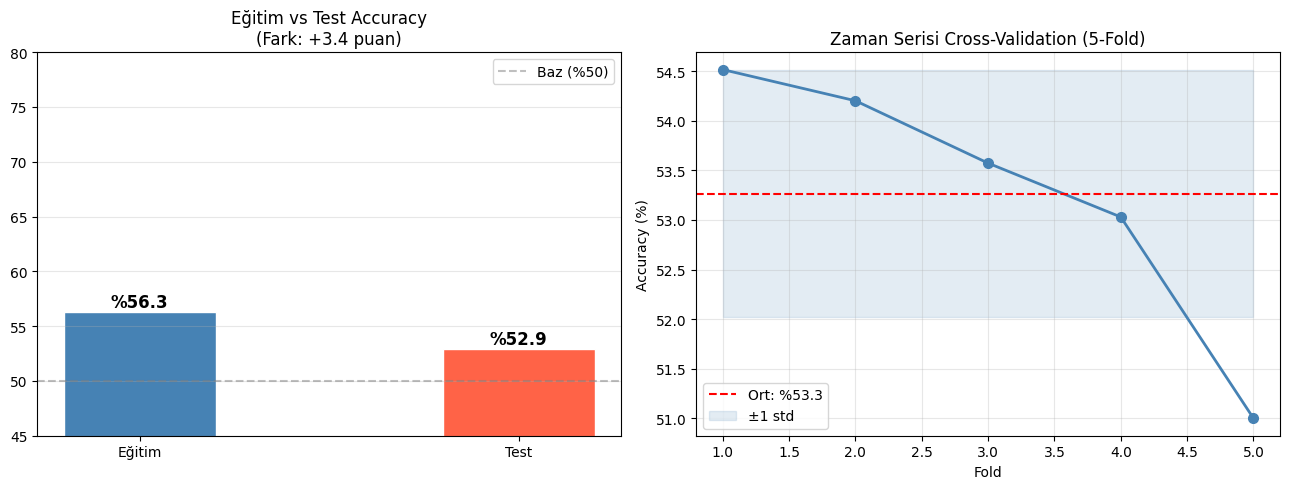

In [13]:
# ─────────────────────────────────────────────
# ADIM 11: OVERFİTTİNG TESTİ
# Eğitim vs Test skorları karşılaştırılır.
# ─────────────────────────────────────────────
from sklearn.metrics import roc_auc_score

# Olasılık ve tahminler
train_prob  = hybrid_model.predict_proba(X_train)[:, 1]
train_pred2 = hybrid_model.predict(X_train)
test_prob2  = hybrid_model.predict_proba(X_test)[:, 1]
test_pred2  = hybrid_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred2) * 100
test_acc  = accuracy_score(y_test,  test_pred2)  * 100
train_auc = roc_auc_score(y_train, train_prob)
test_auc  = roc_auc_score(y_test,  test_prob2)
fark_acc  = train_acc - test_acc

# Sonuç
print('=' * 52)
print('🔬 OVERFİTTİNG ANALİZİ')
print(f'Eğitim Accuracy : %{train_acc:.2f}')
print(f'Test  Accuracy  : %{test_acc:.2f}')
print(f'Fark (Train-Test): {fark_acc:+.2f} puan')
print(f'Eğitim AUC      : {train_auc:.4f}')
print(f'Test  AUC       : {test_auc:.4f}')
print('-' * 52)
if fark_acc > 10:
    print('⚠️  OVERFİTTİNG VAR — Fark >10 puan!')
    print('   → max_depth düşür veya min_samples_split artır.')
elif fark_acc > 5:
    print('🟡 HAFIF OVERFİTTİNG — Fark 5-10 puan arası.')
    print('   → Kabul edilebilir ama izlenmeye devam et.')
else:
    print('✅ Belirgin overfitting görülmedi; ancak model başarımı sınırlı seviyededir.')
print('=' * 52)

# Cross-validation ile daha sağlam test
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

tscv       = TimeSeriesSplit(n_splits=5)
cv_scores  = cross_val_score(
    hybrid_model, X_train, y_train,
    cv=tscv, scoring='accuracy', n_jobs=-1
) * 100

print(f'\n📊 Zaman Serisi CV (5-Fold)')
print(f'Fold Skorları : {[f"{s:.1f}%" for s in cv_scores]}')
print(f'Ortalama      : %{cv_scores.mean():.2f} ± {cv_scores.std():.2f}')
if cv_scores.std() > 5:
    print('⚠️  Yüksek varyans — model dönemlere göre tutarsız.')
else:
    print('✅ Stabil — fold')

# Görsel: Eğitim vs Test skor karşılaştırması + CV
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(['Eğitim', 'Test'], [train_acc, test_acc],
           color=['steelblue', 'tomato'], width=0.4, edgecolor='white')
axes[0].set_ylim(45, 80)
axes[0].axhline(50, color='gray', ls='--', alpha=0.5, label='Baz (%50)')
for i, v in enumerate([train_acc, test_acc]):
    axes[0].text(i, v + 0.5, f'%{v:.1f}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title(f'Eğitim vs Test Accuracy\n(Fark: {fark_acc:+.1f} puan)', fontsize=12)
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')

axes[1].plot(range(1, 6), cv_scores, marker='o', color='steelblue', lw=2, ms=7)
axes[1].axhline(cv_scores.mean(), color='red', ls='--', label=f'Ort: %{cv_scores.mean():.1f}')
axes[1].fill_between(range(1, 6),
    cv_scores.mean() - cv_scores.std(),
    cv_scores.mean() + cv_scores.std(),
    alpha=0.15, color='steelblue', label='±1 std')
axes[1].set_title('Zaman Serisi Cross-Validation (5-Fold)', fontsize=12)
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

💸 KOMİSYON ETKİSİ ANALİZİ
Gerçek Bakiye (komisyonlu)  : $12,662.19  (+26.62%)
Teorik Bakiye (komisyonsuz) : $12,819.85  (+28.20%)
Komisyonun Getiriye Etkisi  : +1.58 puan
Toplam Komisyon Maliyeti    : $157.67
İşlem Başına Ort. Komisyon  : $0.91
-------------------------------------------------------
💡 Komisyon sıfır olsaydı ek kazanç: $157.67
💡 Komisyonu kırmak için gereken ek getiri: %1.58
💡 Varsayımsal komisyon indirimi (%25) uygulanırsa tasarruf: $39.42


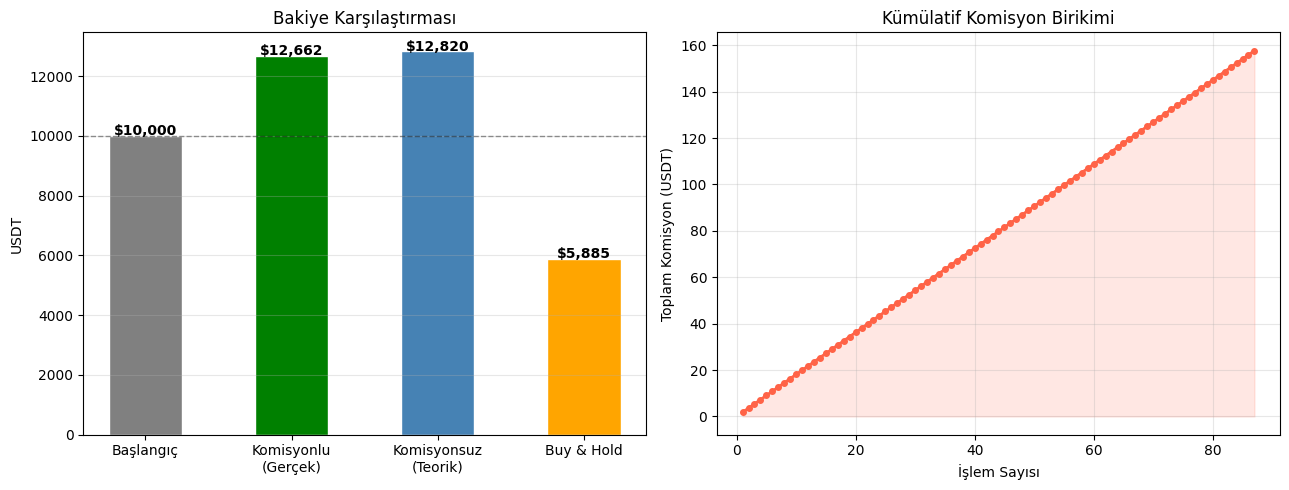

In [15]:
# ─────────────────────────────────────────────
# ADIM 12: KOMİSYONSUZ KAZANÇ ANALİZİ
# Komisyonun toplam getiriye etkisini gösterir.
# islem_df ve toplam_komisyon Adım 8'de tanımlı.
# ─────────────────────────────────────────────
bah_getiri = (
    (test_df['Kapanis'].iloc[-1] - test_df['Kapanis'].iloc[0])
    / test_df['Kapanis'].iloc[0]
) * 100

if len(islem_df) == 0:
    print('Hiç işlem yok — önce Adım 8\'i çalıştır.')
else:
    komisyonlu_bakiye   = bakiye
    komisyonsuz_bakiye  = bakiye + toplam_komisyon
    komisyonlu_getiri   = (komisyonlu_bakiye  - BASLANGIC) / BASLANGIC * 100
    komisyonsuz_getiri  = (komisyonsuz_bakiye - BASLANGIC) / BASLANGIC * 100
    komisyon_etkisi     = komisyonsuz_getiri - komisyonlu_getiri

    # İşlem başına ortalama komisyon
    islem_basi_kom  = toplam_komisyon / max(1, len(islem_df))
    # Komisyon geri kazanılsaydı break-even fiyatı
    breakeven_artiş = (toplam_komisyon / BASLANGIC) * 100

    print('=' * 55)
    print('💸 KOMİSYON ETKİSİ ANALİZİ')
    print(f'Gerçek Bakiye (komisyonlu)  : ${komisyonlu_bakiye:,.2f}  ({komisyonlu_getiri:+.2f}%)')
    print(f'Teorik Bakiye (komisyonsuz) : ${komisyonsuz_bakiye:,.2f}  ({komisyonsuz_getiri:+.2f}%)')
    print(f'Komisyonun Getiriye Etkisi  : {komisyon_etkisi:+.2f} puan')
    print(f'Toplam Komisyon Maliyeti    : ${toplam_komisyon:,.2f}')
    print(f'İşlem Başına Ort. Komisyon  : ${islem_basi_kom:.2f}')
    print('-' * 55)
    print(f'💡 Komisyon sıfır olsaydı ek kazanç: ${toplam_komisyon:,.2f}')
    print(f'💡 Komisyonu kırmak için gereken ek getiri: %{breakeven_artiş:.2f}')

    # BNB ile ödeme önerisi
    bnb_komisyon  = toplam_komisyon * 0.75
    bnb_kazanim   = toplam_komisyon - bnb_komisyon
    print(f'💡 Varsayımsal komisyon indirimi (%25) uygulanırsa tasarruf: ${bnb_kazanim:,.2f}')
    print('=' * 55)

    # Görsel
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Sol: Komisyonlu vs Komisyonsuz bakiye karşılaştırması
    labels  = ['Başlangıç', 'Komisyonlu\n(Gerçek)', 'Komisyonsuz\n(Teorik)', 'Buy & Hold']
    bah_son = BASLANGIC * (1 + bah_getiri / 100)
    degerler= [BASLANGIC, komisyonlu_bakiye, komisyonsuz_bakiye, bah_son]
    renkler = ['gray', 'tomato' if komisyonlu_bakiye < BASLANGIC else 'green',
               'steelblue', 'orange']
    bars = axes[0].bar(labels, degerler, color=renkler, width=0.5, edgecolor='white')
    axes[0].axhline(BASLANGIC, color='black', ls='--', lw=1, alpha=0.4)
    for bar, val in zip(bars, degerler):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                   val + 30, f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')
    axes[0].set_title('Bakiye Karşılaştırması', fontsize=12)
    axes[0].set_ylabel('USDT'); axes[0].grid(True, alpha=0.3, axis='y')

    # Sağ: Kümülatif komisyon birikimi
    al_idxler    = islem_df[islem_df['Tip'] == 'AL'].index
    kom_per_islem= [islem_basi_kom * 2] * len(al_idxler)
    kumlatif     = np.cumsum(kom_per_islem)
    axes[1].plot(range(1, len(kumlatif)+1), kumlatif,
                color='tomato', lw=2, marker='o', ms=4)
    axes[1].fill_between(range(1, len(kumlatif)+1), kumlatif, alpha=0.15, color='tomato')
    axes[1].set_title('Kümülatif Komisyon Birikimi', fontsize=12)
    axes[1].set_xlabel('İşlem Sayısı'); axes[1].set_ylabel('Toplam Komisyon (USDT)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()